<a href="https://colab.research.google.com/github/Bhawna013/UrbanKart-Ecommerce-Analytics/blob/main/UrbanKart_Sales_Analystic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")

In [3]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

In [4]:
orders = orders[orders["order_status"] == "Delivered"].copy()

In [5]:
analysis_date = orders["order_date"].max() + pd.Timedelta(days=1)

print(analysis_date)

2025-01-01 00:00:00


# RFM ANALYSIS

In [6]:
rfm = orders.groupby("customer_id").agg(
    Recency=("order_date", lambda x: (analysis_date - x.max()).days),
    Frequency=("order_id", "count"),
    Monetary=("total_amount", "sum")
).reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,100001,44,1,15031.03
1,100002,45,8,269485.05
2,100003,63,3,145662.76
3,100004,296,4,172909.55
4,100005,292,1,1144.00


In [8]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
).astype(int)

In [9]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [10]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [11]:
rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,100001,44,1,15031.03,4,1,2,7
1,100002,45,8,269485.05,4,5,5,14
2,100003,63,3,145662.76,4,3,4,11
3,100004,296,4,172909.55,2,4,4,10
4,100005,292,1,1144.00,2,1,1,4


In [12]:
def segment_customer(score):

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 8:
        return "Potential Loyalists"

    elif score >= 6:
        return "At Risk"

    else:
        return "Lost Customers"

In [13]:
rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,100001,44,1,15031.03,4,1,2,7,At Risk
1,100002,45,8,269485.05,4,5,5,14,Champions
2,100003,63,3,145662.76,4,3,4,11,Loyal Customers
3,100004,296,4,172909.55,2,4,4,10,Loyal Customers
4,100005,292,1,1144.00,2,1,1,4,Lost Customers


In [21]:
rfm_with_names = rfm.merge(customers[['customer_id', 'first_name', 'last_name']], on='customer_id', how='left')

In [22]:
rfm_with_names.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,first_name,last_name
0,100001,44,1,15031.03,4,1,2,7,At Risk,Jhalak,Sachar
1,100002,45,8,269485.05,4,5,5,14,Champions,Xavier,Kulkarni
2,100003,63,3,145662.76,4,3,4,11,Loyal Customers,Jackson,Gour
3,100004,296,4,172909.55,2,4,4,10,Loyal Customers,Hemal,Oak
4,100005,292,1,1144.00,2,1,1,4,Lost Customers,Ishaan,Gour


In [14]:
segment_summary = (
    rfm.groupby("Segment")
       .agg(
            Customers=("customer_id", "count"),
            Avg_Recency=("Recency", "mean"),
            Avg_Frequency=("Frequency", "mean"),
            Avg_Monetary=("Monetary", "mean")
       )
       .round(2)
)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,19246,303.83,1.23,33450.55
Champions,19969,30.58,9.76,338574.74
Lost Customers,18161,554.22,1.01,11971.53
Loyal Customers,21411,104.14,3.88,126948.46
Potential Loyalists,16562,184.96,1.94,59885.34


In [15]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .sort_values(ascending=False)
)

print(segment_counts)

Segment
Loyal Customers        21411
Champions              19969
At Risk                19246
Lost Customers         18161
Potential Loyalists    16562
Name: count, dtype: int64


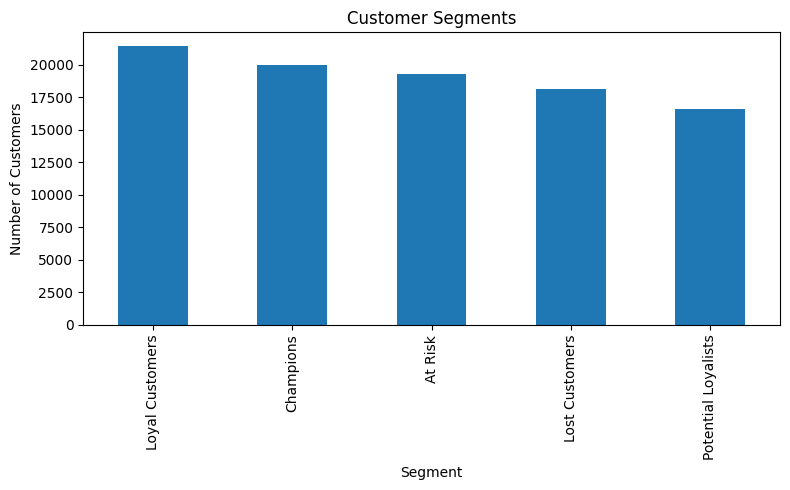

In [16]:
plt.figure(figsize=(8,5))

segment_counts.plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [24]:
rfm_with_names.sort_values(
    by="Monetary",
    ascending=False
)[[
    "customer_id",
    "first_name",
    "last_name",
    "Segment",
    "Monetary",
    "Frequency",
    "Recency"
]].head(10)

,customer_id,first_name,last_name,Segment,Monetary,Frequency,Recency
4492,104718,Indira,Parsa,Champions,1887428.47,31,39
26587,127877,Jeremiah,Kunda,Champions,1842547.86,34,2
65583,168761,Azad,Chandran,Champions,1838092.16,31,27
25562,126799,Peter,Bal,Champions,1825297.69,37,24
84264,188361,Bina,Zachariah,Champions,1783814.13,36,26
3224,103396,Vidhi,Bail,Champions,1752604.68,38,9
21377,122417,Faras,Ravel,Champions,1740785.34,31,44
7341,107701,Gaurika,Sama,Champions,1739417.82,34,23
55988,158693,Sneha,Dube,Champions,1738295.21,28,12
79117,182967,Mohini,Sodhi,Champions,1709071.55,32,8


In [25]:
rfm.to_csv("rfm_customer_segmentation.csv", index=False)

# COHORT ANALYSIS

After customers place their first order, how many return in subsequent months?
A high retention rate generally indicates strong customer satisfaction and repeat purchasing.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
orders = pd.read_csv("orders.csv")
orders["order_date"] = pd.to_datetime(orders["order_date"])



In [28]:
# Only delivered orders
orders = orders[orders["order_status"] == "Delivered"].copy()

Create Order Month

In [30]:
orders["OrderMonth"] = orders["order_date"].dt.to_period("M")

Find first purchase month(cohort month)

In [31]:
orders["CohortMonth"] = (
    orders
    .groupby("customer_id")["OrderMonth"]
    .transform("min")
)

Calculate Cohort Index

This calculates how many months have passed since the customer's first purchase.

In [32]:
orders["CohortIndex"] = (
    (orders["OrderMonth"].dt.year - orders["CohortMonth"].dt.year) * 12
    +
    (orders["OrderMonth"].dt.month - orders["CohortMonth"].dt.month)
)

Count Active Customers

In [33]:
cohort_data = (
    orders.groupby(["CohortMonth", "CohortIndex"])
    ["customer_id"]
    .nunique()
    .reset_index()
)

cohort_data.head()

,CohortMonth,CohortIndex,customer_id
0,2021-01,0,63
1,2021-01,1,4
2,2021-01,2,6
3,2021-01,3,1
4,2021-01,4,9


Create Cohort Table

In [38]:
cohort_table = cohort_data.pivot(
    index = "CohortMonth",
    columns = "CohortIndex",
    values="customer_id"
)

cohort_table

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2021-01,63.0,4.0,6.0,1.0,9.0,4.0,15.0,15.0,6.0,12.0,...,5.0,8.0,4.0,8.0,8.0,9.0,12.0,14.0,13.0,13.0
2021-02,131.0,11.0,15.0,10.0,11.0,16.0,25.0,17.0,26.0,26.0,...,13.0,9.0,12.0,15.0,18.0,17.0,23.0,28.0,17.0,NaN
2021-03,269.0,16.0,30.0,26.0,26.0,36.0,46.0,52.0,55.0,36.0,...,23.0,29.0,29.0,45.0,37.0,51.0,56.0,47.0,NaN,NaN
2021-04,285.0,33.0,26.0,26.0,27.0,40.0,60.0,59.0,42.0,36.0,...,35.0,29.0,36.0,41.0,55.0,49.0,37.0,NaN,NaN,NaN
2021-05,424.0,32.0,59.0,40.0,61.0,72.0,106.0,80.0,52.0,48.0,...,47.0,62.0,49.0,71.0,85.0,63.0,NaN,NaN,NaN,NaN
2021-06,482.0,57.0,66.0,84.0,99.0,110.0,73.0,53.0,50.0,52.0,...,58.0,76.0,84.0,96.0,63.0,NaN,NaN,NaN,NaN,NaN
2021-07,623.0,69.0,91.0,109.0,131.0,84.0,66.0,49.0,71.0,50.0,...,82.0,103.0,127.0,111.0,NaN,NaN,NaN,NaN,NaN,NaN
2021-08,919.0,100.0,159.0,160.0,121.0,84.0,85.0,97.0,81.0,76.0,...,141.0,182.0,132.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09,964.0,160.0,166.0,130.0,96.0,76.0,81.0,70.0,63.0,88.0,...,173.0,134.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Retention Rate

the first month's customer count becomes the denominator

In [39]:
cohort_size = cohort_table.iloc[:,0]

retention = cohort_table.divide(
    cohort_size,
    axis = 0
).round(3)

retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2021-01,1.0,0.063,0.095,0.016,0.143,0.063,0.238,0.238,0.095,0.190,...,0.079,0.127,0.063,0.127,0.127,0.143,0.190,0.222,0.206,0.206
2021-02,1.0,0.084,0.115,0.076,0.084,0.122,0.191,0.130,0.198,0.198,...,0.099,0.069,0.092,0.115,0.137,0.130,0.176,0.214,0.130,NaN
2021-03,1.0,0.059,0.112,0.097,0.097,0.134,0.171,0.193,0.204,0.134,...,0.086,0.108,0.108,0.167,0.138,0.190,0.208,0.175,NaN,NaN
2021-04,1.0,0.116,0.091,0.091,0.095,0.140,0.211,0.207,0.147,0.126,...,0.123,0.102,0.126,0.144,0.193,0.172,0.130,NaN,NaN,NaN
2021-05,1.0,0.075,0.139,0.094,0.144,0.170,0.250,0.189,0.123,0.113,...,0.111,0.146,0.116,0.167,0.200,0.149,NaN,NaN,NaN,NaN
2021-06,1.0,0.118,0.137,0.174,0.205,0.228,0.151,0.110,0.104,0.108,...,0.120,0.158,0.174,0.199,0.131,NaN,NaN,NaN,NaN,NaN
2021-07,1.0,0.111,0.146,0.175,0.210,0.135,0.106,0.079,0.114,0.080,...,0.132,0.165,0.204,0.178,NaN,NaN,NaN,NaN,NaN,NaN
2021-08,1.0,0.109,0.173,0.174,0.132,0.091,0.092,0.106,0.088,0.083,...,0.153,0.198,0.144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09,1.0,0.166,0.172,0.135,0.100,0.079,0.084,0.073,0.065,0.091,...,0.179,0.139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Convert to Percentage

In [40]:
retention = retention * 100

retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2021-01,100.0,6.3,9.5,1.6,14.3,6.3,23.8,23.8,9.5,19.0,...,7.9,12.7,6.3,12.7,12.7,14.3,19.0,22.2,20.6,20.6
2021-02,100.0,8.4,11.5,7.6,8.4,12.2,19.1,13.0,19.8,19.8,...,9.9,6.9,9.2,11.5,13.7,13.0,17.6,21.4,13.0,NaN
2021-03,100.0,5.9,11.2,9.7,9.7,13.4,17.1,19.3,20.4,13.4,...,8.6,10.8,10.8,16.7,13.8,19.0,20.8,17.5,NaN,NaN
2021-04,100.0,11.6,9.1,9.1,9.5,14.0,21.1,20.7,14.7,12.6,...,12.3,10.2,12.6,14.4,19.3,17.2,13.0,NaN,NaN,NaN
2021-05,100.0,7.5,13.9,9.4,14.4,17.0,25.0,18.9,12.3,11.3,...,11.1,14.6,11.6,16.7,20.0,14.9,NaN,NaN,NaN,NaN
2021-06,100.0,11.8,13.7,17.4,20.5,22.8,15.1,11.0,10.4,10.8,...,12.0,15.8,17.4,19.9,13.1,NaN,NaN,NaN,NaN,NaN
2021-07,100.0,11.1,14.6,17.5,21.0,13.5,10.6,7.9,11.4,8.0,...,13.2,16.5,20.4,17.8,NaN,NaN,NaN,NaN,NaN,NaN
2021-08,100.0,10.9,17.3,17.4,13.2,9.1,9.2,10.6,8.8,8.3,...,15.3,19.8,14.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09,100.0,16.6,17.2,13.5,10.0,7.9,8.4,7.3,6.5,9.1,...,17.9,13.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


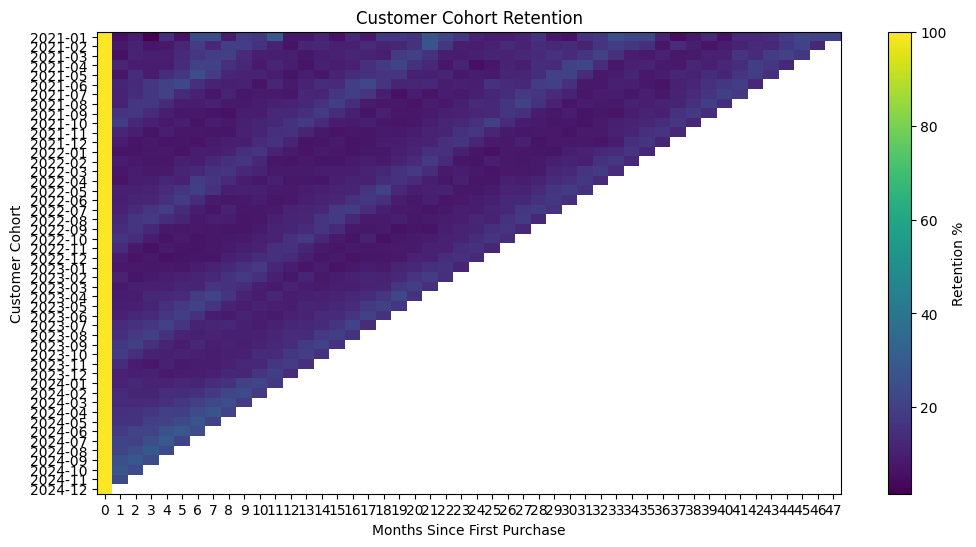

In [41]:
plt.figure(figsize=(12,6))

plt.imshow(retention, aspect ="auto")

plt.colorbar(label ="Retention %")

plt.xticks(
    range(len(retention.columns)),
    retention.columns
)

plt.yticks(
    range(len(retention.index)),
    retention.index.astype(str)
)

plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")
plt.title("Customer Cohort Retention")

plt.show()

Average Retention by Month

In [42]:
average_retention = retention.mean(axis=0)

average_retention

,0
CohortIndex,
0,100.000000
1,13.100000
2,13.410870
3,12.828889
4,13.363636
5,13.016279
6,13.788095
7,13.165854
8,12.562500


Retention Trend

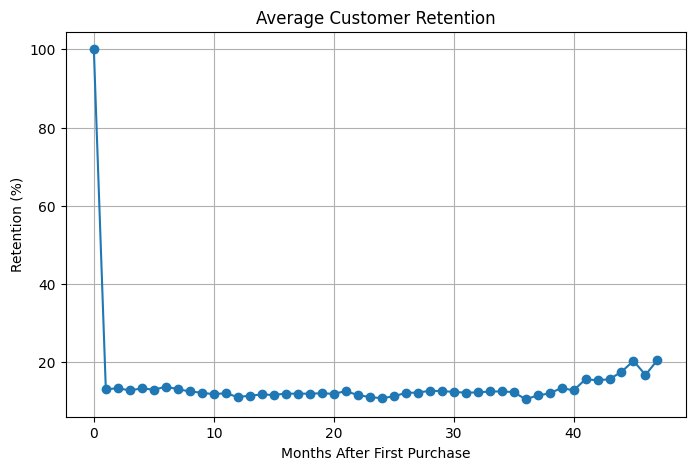

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o"
)

plt.title("Average Customer Retention")

plt.xlabel("Months After First Purchase")

plt.ylabel("Retention (%)")

plt.grid(True)

plt.show()


# CUSTOMER LIFETIME VALUE(CLV) ANALYSIS

In [45]:
clv = (
    orders.groupby("customer_id")
    .agg(
        Total_Orders = ("order_id", "count"),
        Total_Revenue = ("total_amount", "sum"),
        Average_Order_Value = ("total_amount", "mean"),
        First_Purchase =("order_date", "min"),
        Last_Purchase = ("order_date", "max")
    )
    .reset_index()
    )

clv.head()

,customer_id,Total_Orders,Total_Revenue,Average_Order_Value,First_Purchase,Last_Purchase
0,100001,1,15031.03,15031.030000,2024-11-18,2024-11-18
1,100002,8,269485.05,33685.631250,2022-05-16,2024-11-17
2,100003,3,145662.76,48554.253333,2022-06-16,2024-10-30
3,100004,4,172909.55,43227.387500,2023-09-04,2024-03-11
4,100005,1,1144.00,1144.000000,2024-03-15,2024-03-15


Customer Lifespan

In [46]:
clv["Customer_Lifespan_Days"] = (
    clv["Last_Purchase"] -
    clv["First_Purchase"]
).dt.days + 1

Estimate CLV
CLV = AOV * TOTAL ORDERS

In [47]:
clv["CLV"] = (
    clv["Average_Order_Value"] *
    clv["Total_Orders"]
).round(2)

Merge Customer information

In [48]:
clv = clv.merge(
    customers[
        [
            "customer_id",
            "first_name",
            "last_name",
            "city",
            "state",
            "acquisition_channel",
            "loyalty_tier"
        ]
    ],
    on="customer_id",
    how="left"
)

clv.head()

,customer_id,Total_Orders,Total_Revenue,Average_Order_Value,First_Purchase,Last_Purchase,Customer_Lifespan_Days,CLV,first_name,last_name,city,state,acquisition_channel,loyalty_tier
0,100001,1,15031.03,15031.030000,2024-11-18,2024-11-18,1,15031.03,Jhalak,Sachar,Kolkata,West Bengal,Organic,Bronze
1,100002,8,269485.05,33685.631250,2022-05-16,2024-11-17,917,269485.05,Xavier,Kulkarni,Mumbai,Maharashtra,Email,Bronze
2,100003,3,145662.76,48554.253333,2022-06-16,2024-10-30,868,145662.76,Jackson,Gour,Mumbai,Maharashtra,Meta Ads,Bronze
3,100004,4,172909.55,43227.387500,2023-09-04,2024-03-11,190,172909.55,Hemal,Oak,Chennai,Tamil Nadu,Google Ads,Gold
4,100005,1,1144.00,1144.000000,2024-03-15,2024-03-15,1,1144.00,Ishaan,Gour,Jaipur,Rajasthan,Organic,Bronze


Summary Statistics

In [49]:
clv[["CLV"]].describe().round(2)

,CLV
count,95349.00
mean,118848.84
std,165958.13
min,125.23
25%,13949.47
50%,57261.98
75%,154807.55
max,1887428.47


Top 10 Customers

In [50]:
top_customers = (
    clv.sort_values(
        by = "CLV",
        ascending = False
    )
)

top_customers[
    [
        "customer_id",
        "first_name",
        "last_name",
        "CLV",
        "Total_Orders",
        "Average_Order_Value"
    ]
].head(10)

,customer_id,first_name,last_name,CLV,Total_Orders,Average_Order_Value
4492,104718,Indira,Parsa,1887428.47,31,60884.789355
26587,127877,Jeremiah,Kunda,1842547.86,34,54192.584118
65583,168761,Azad,Chandran,1838092.16,31,59293.295484
25562,126799,Peter,Bal,1825297.69,37,49332.370000
84264,188361,Bina,Zachariah,1783814.13,36,49550.392500
3224,103396,Vidhi,Bail,1752604.68,38,46121.175789
21377,122417,Faras,Ravel,1740785.34,31,56154.365806
7341,107701,Gaurika,Sama,1739417.82,34,51159.347647
55988,158693,Sneha,Dube,1738295.21,28,62081.971786
79117,182967,Mohini,Sodhi,1709071.55,32,53408.485938


CLV DISTRIBUTION

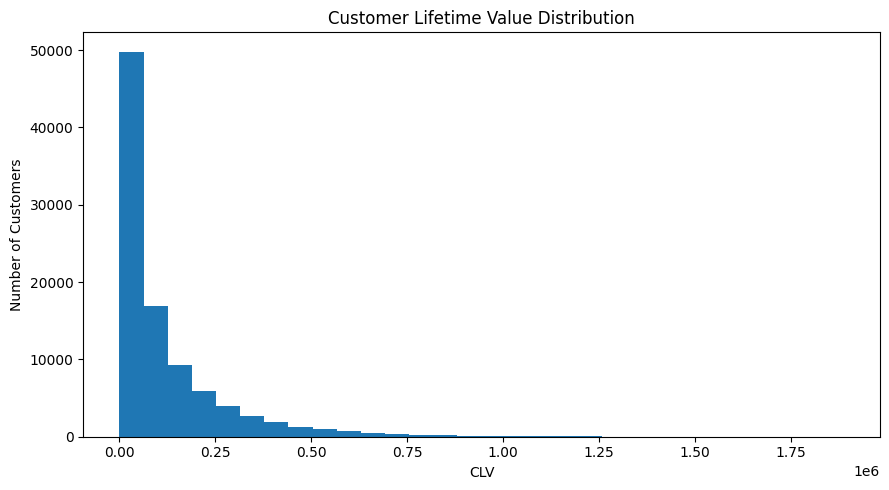

In [56]:
plt.figure(figsize=(9,5))

plt.hist(
    clv["CLV"],
    bins = 30
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

CLV by Loyalty Tier

In [57]:
tier_clv = (
    clv.groupby("loyalty_tier")
    ["CLV"]
    .mean()
    .sort_values(ascending=False)
)

tier_clv


,CLV
loyalty_tier,
Gold,121120.150811
Silver,119417.744642
Bronze,118335.860406
Platinum,117647.548957


Visualize CLV by Loyalty Tier

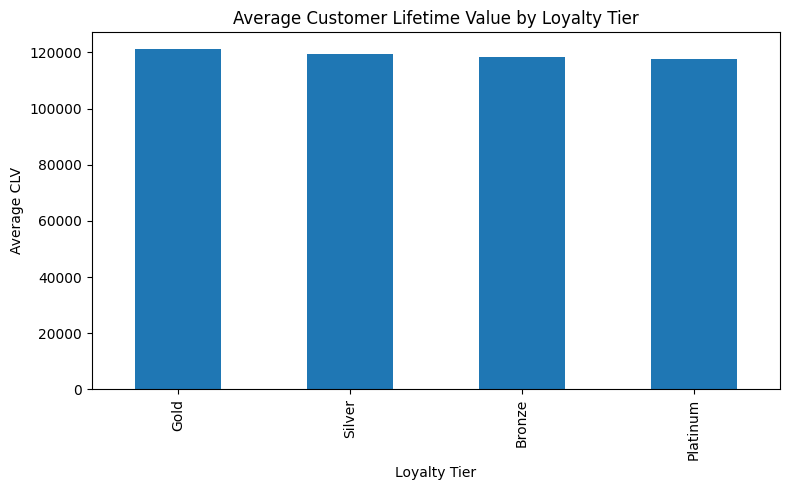

In [58]:
plt.figure(figsize=(8,5))

tier_clv.plot(kind="bar")

plt.title("Average Customer Lifetime Value by Loyalty Tier")
plt.xlabel("Loyalty Tier")
plt.ylabel("Average CLV")

plt.tight_layout()
plt.show()

CLV by Acquisition Channel

In [59]:
channel_clv = (
    clv.groupby("acquisition_channel")
    ["CLV"]
    .mean()
    .sort_values(ascending=False)
)

channel_clv


,CLV
acquisition_channel,
Referral,122369.205623
Meta Ads,120481.543827
Affiliate,120334.995287
Google Ads,118962.948278
Organic,117356.930897
Email,117282.135841


Visualise CLV by Acquisition Channel

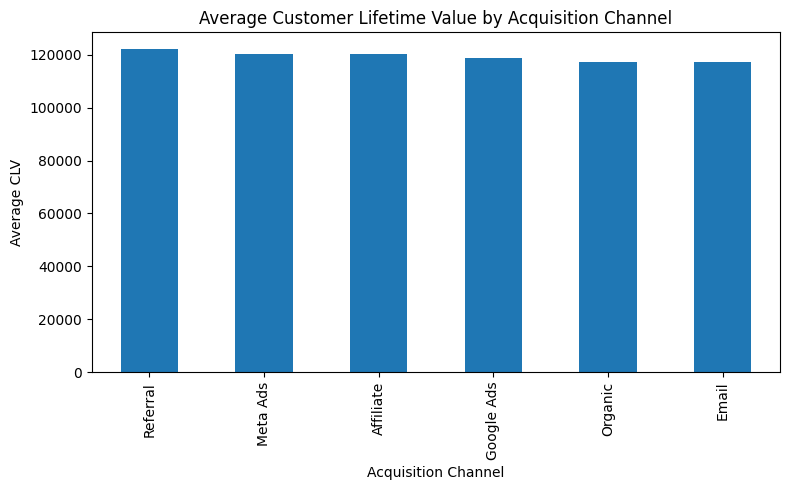

In [60]:
plt.figure(figsize=(8,5))

channel_clv.plot(kind="bar")

plt.title("Average Customer Lifetime Value by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Average CLV")

plt.tight_layout()
plt.show()

CLV Segmentation

In [61]:
clv["CLV_Segment"] = pd.qcut(
    clv["CLV"],
    q = 4,
    labels = ["Low", "Medium", "High", "Very High"]
)



Segment Counts

In [62]:
segment_counts = (
    clv["CLV_Segment"]
    .value_counts()
    .sort_index()
)

print(segment_counts)

CLV_Segment
Low          23838
Medium       23837
High         23837
Very High    23837
Name: count, dtype: int64


Visualise CLV segments

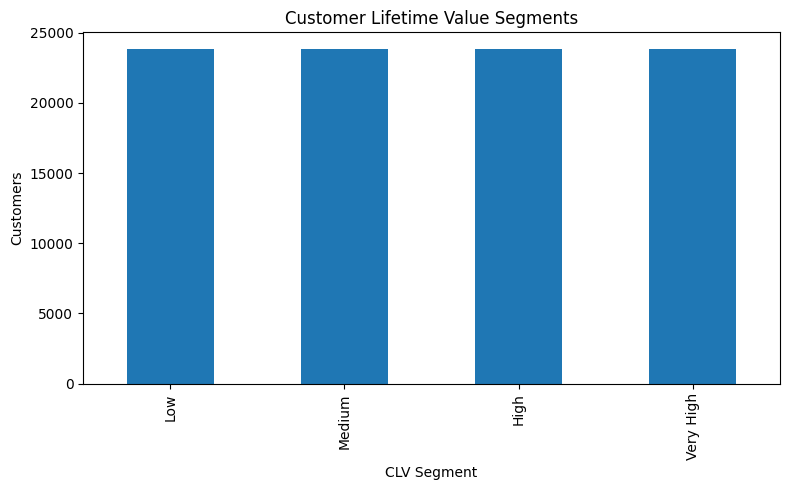

In [63]:
plt.figure(figsize=(8,5))

segment_counts.plot(kind="bar")

plt.title("Customer Lifetime Value Segments")
plt.xlabel("CLV Segment")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()

# TIME SERIES ANALYSIS

In [7]:
orders = pd.read_csv("orders.csv")
customers = pd.read_csv("customers.csv")
returns = pd.read_csv("returns.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")
categories = pd.read_csv("categories.csv")

In [8]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
returns["return_date"] = pd.to_datetime(returns["return_date"])

orders = orders[orders["order_status"] == "Delivered"].copy()

MONTHLY REVENUE TREND

In [9]:
orders["Month"] = orders["order_date"].dt.to_period("M")

monthly_revenue = (
    orders.groupby("Month")["total_amount"]
    .sum()
    .reset_index()
)

monthly_revenue["Month"] = monthly_revenue["Month"].astype(str)

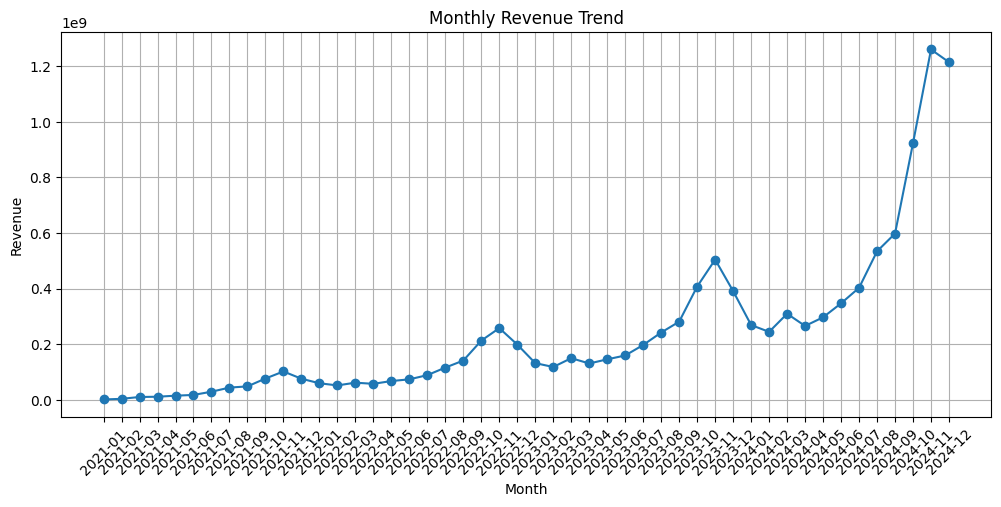

In [10]:
plt.figure(figsize=(12,5))
plt.plot(monthly_revenue["Month"],
         monthly_revenue["total_amount"],
         marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

MONTHLY ORDERS TREND

In [11]:
monthly_orders = (
    orders.groupby("Month")["order_id"]
    .count()
    .reset_index(name="Orders")
)

monthly_orders["Month"] = monthly_orders["Month"].astype(str)

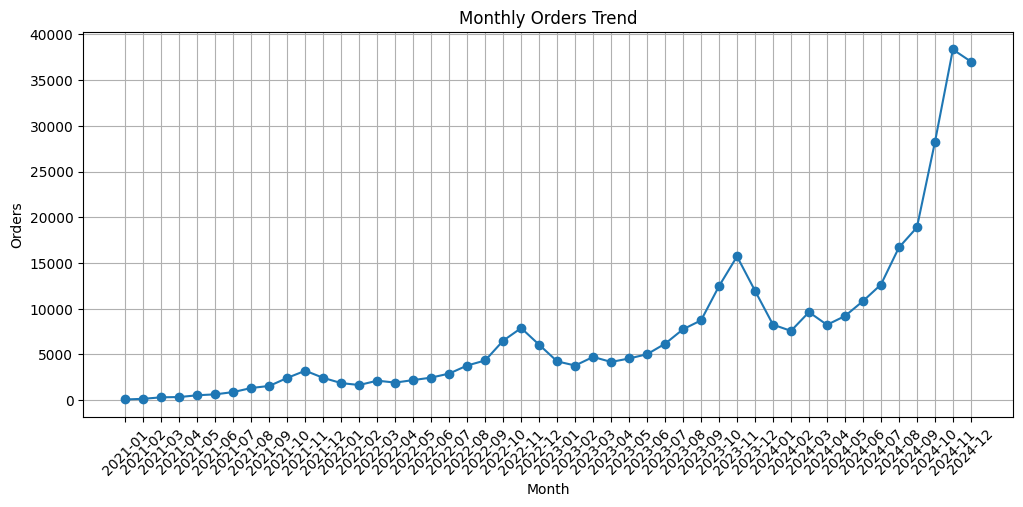

In [12]:
plt.figure(figsize=(12,5))
plt.plot(monthly_orders["Month"],
         monthly_orders["Orders"],
         marker="o")

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

MONTHLY AOV

In [13]:
monthly_aov = (
    orders.groupby("Month")["total_amount"]
    .mean()
    .reset_index(name="AOV")
)

monthly_aov["Month"] = monthly_aov["Month"].astype(str)

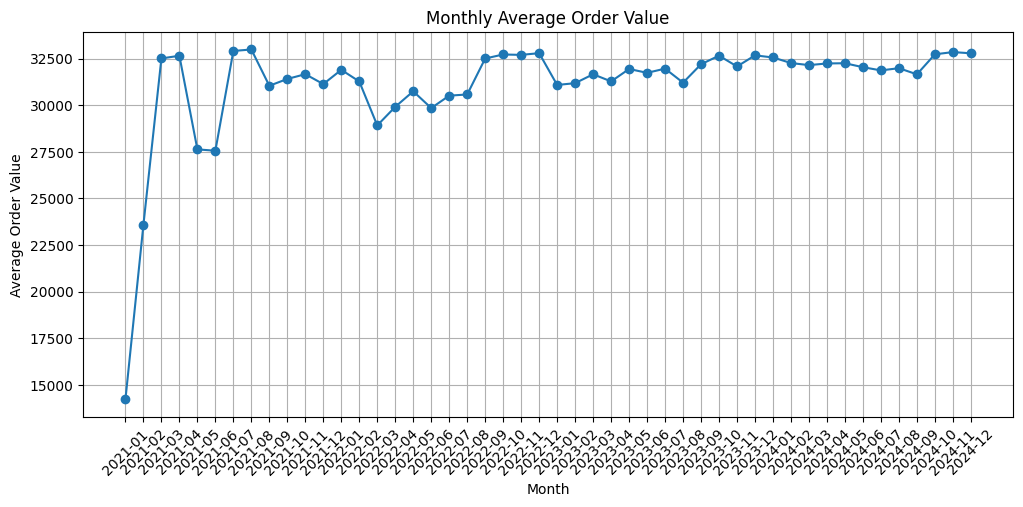

In [14]:
plt.figure(figsize=(12,5))
plt.plot(monthly_aov["Month"],
         monthly_aov["AOV"],
         marker="o")

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

MONTHLY NEW CUSTOMER SIGNUPS

In [15]:
customers["Signup_Month"] = customers["signup_date"].dt.to_period("M")



In [16]:
monthly_signup = (
    customers.groupby("Signup_Month")["customer_id"]
    .count()
    .reset_index(name="New_Customers")
)

monthly_signup["Signup_Month"] = monthly_signup["Signup_Month"].astype(str)

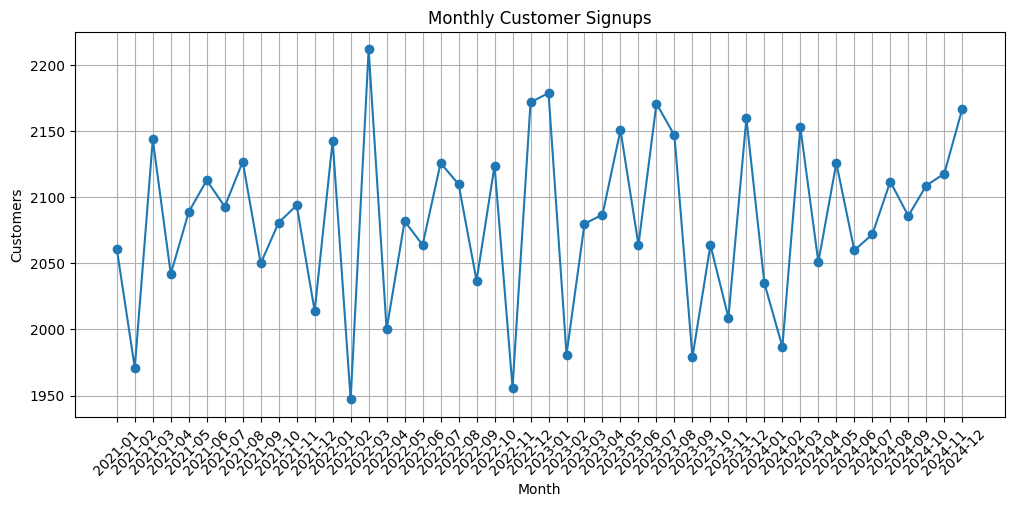

In [17]:
plt.figure(figsize=(12,5))
plt.plot(monthly_signup["Signup_Month"],
         monthly_signup["New_Customers"],
         marker="o")

plt.title("Monthly Customer Signups")
plt.xlabel("Month")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

MONTHLY REVENUE BY CATEGORY

In [18]:
# merge the tables

category_sales = (
    order_items
    .merge(products[["product_id","category_id"]], on="product_id")
    .merge(categories[["category_id","category_name"]], on="category_id")
    .merge(orders[["order_id","order_date"]], on="order_id")
)

In [19]:
# create month

category_sales["Month"] = (
    pd.to_datetime(category_sales["order_date"])
    .dt.to_period("M")
    .astype(str)
)

In [20]:
# aggregate

category_monthly = (
    category_sales.groupby(
        ["Month","category_name"]
    )["line_total"]
    .sum()
    .reset_index()
)

In [21]:
# pivot

pivot = category_monthly.pivot(
    index="Month",
    columns="category_name",
    values="line_total"
).fillna(0)

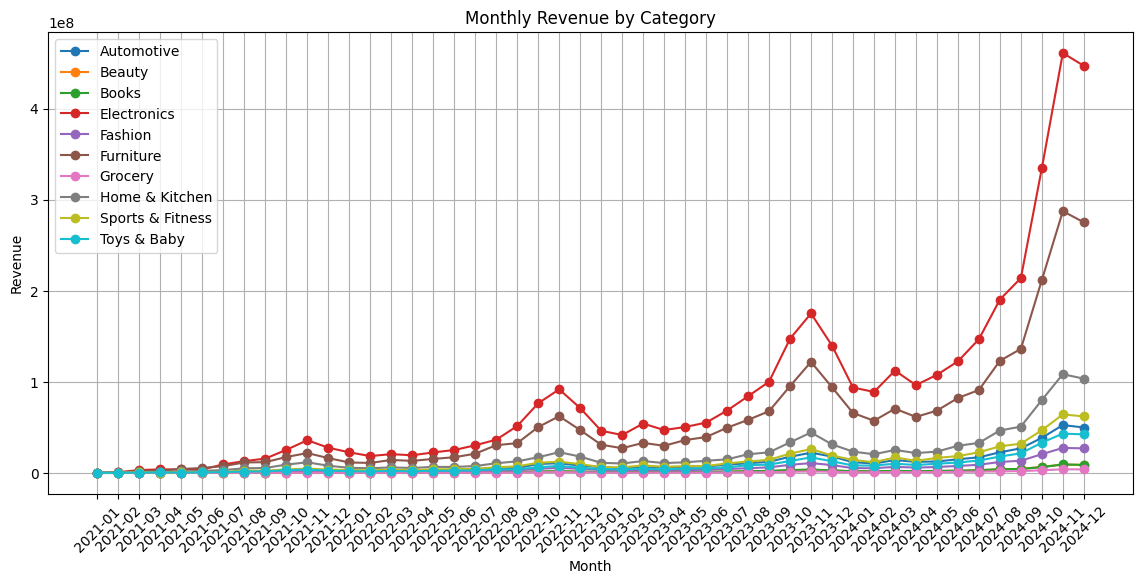

In [22]:
plt.figure(figsize=(14,6))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        marker="o",
        label=col
    )

plt.title("Monthly Revenue by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

MONTHLY REVENUE BY STATE

In [23]:
state_sales = (
    orders.merge(
        customers[
            ["customer_id","state"]
        ],
        on="customer_id"

    )
)

In [24]:
state_sales["Month"] = (
    state_sales["order_date"]
    .dt.to_period("M")
    .astype(str)
)

In [25]:
state_monthly = (
    state_sales.groupby(
        ["Month","state"]
    )["total_amount"]
    .sum()
    .reset_index()
)


In [27]:
pivot = state_monthly.pivot(
    index = "Month",
    columns = "state",
    values = "total_amount"
).fillna(0)

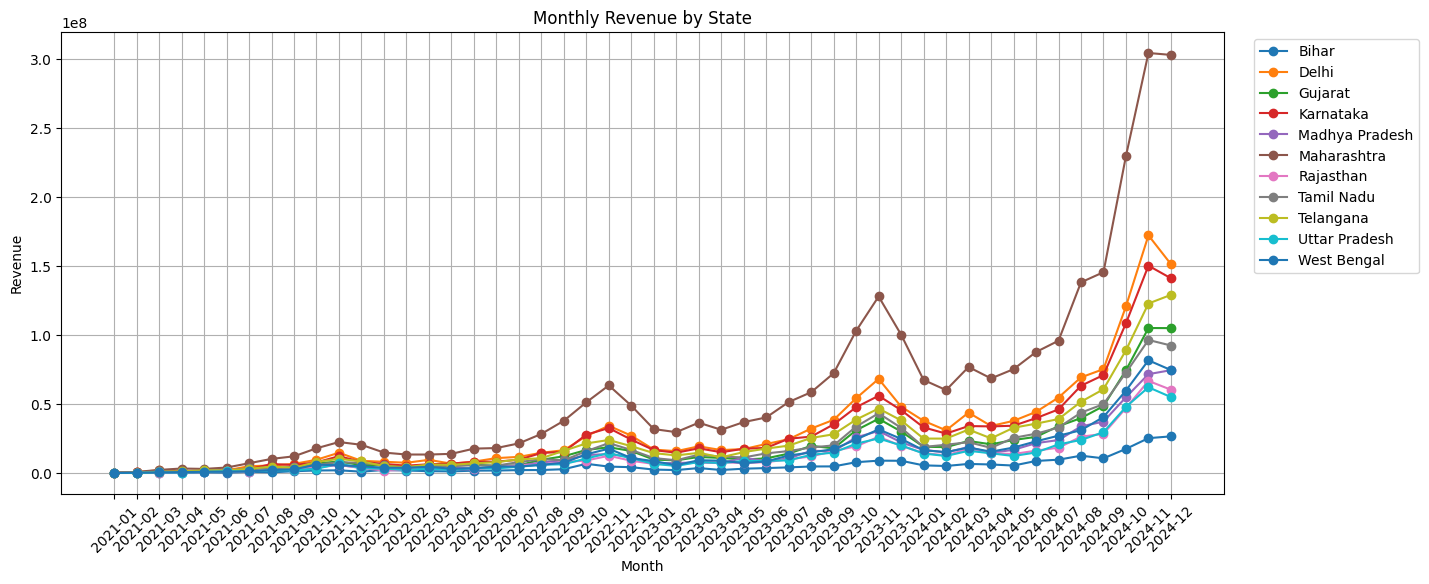

In [28]:
plt.figure(figsize=(15,6))

for state in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[state],
        marker="o",
        label=state
    )

plt.title("Monthly Revenue by State")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02,1))
plt.grid(True)
plt.show()

MONTHLY RETURNS TREND

In [29]:
return_trend = (
    returns.merge(
        orders[["order_id","order_date"]],
        on="order_id"
    )
)

In [30]:
return_trend["Month"] = (
    return_trend["return_date"]
    .dt.to_period("M")
    .astype(str)
)

In [31]:
monthly_returns = (
    return_trend.groupby("Month")["return_id"]
    .count()
    .reset_index(name="Returns")
)

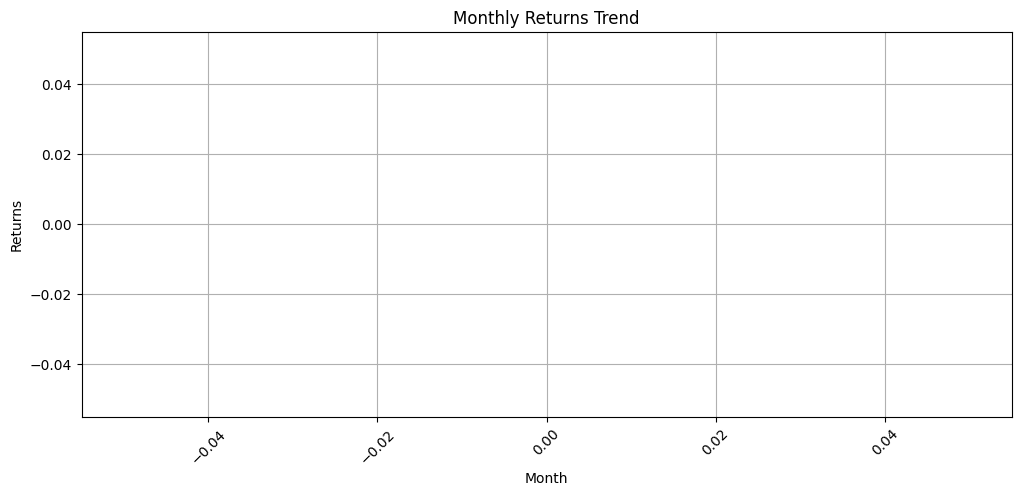

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_returns["Month"],
    monthly_returns["Returns"],
    marker="o"
)

plt.title("Monthly Returns Trend")
plt.xlabel("Month")
plt.ylabel("Returns")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# PRODUCT PERFORMANCE ANALYSIS

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

products = pd.read_csv("products.csv")
order_items = pd.read_csv("order_items.csv")
categories = pd.read_csv("categories.csv")

In [34]:
product_sales = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(categories, on="category_id", how="left")
)

product_sales.head()

,order_item_id,order_id,product_id,quantity,unit_price,gross_amount,discount_percent,discount_amount,line_total,product_name,...,supplier_id,cost_price,selling_price,weight_kg,launch_date,is_active_x,category_name,department,is_active_y,created_date
0,5000001,1000001,5316,1,4801.21,4801.21,10,480.12,4321.09,Van Heusen Cap Plus,...,2018,3166,4801.21,0.37,2022-11-23,True,Fashion,Lifestyle,True,2021-05-20
1,5000002,1000001,6055,1,1447.11,1447.11,20,289.42,1157.69,Cambridge Self Help Book Blue,...,2001,1007,1447.11,0.72,2023-02-05,True,Books,Books,True,2021-10-14
2,5000003,1000001,5669,1,7641.45,7641.45,5,382.07,7259.38,Boldfit Badminton Racket Premium,...,2036,5576,7641.45,12.08,2022-03-03,True,Sports & Fitness,Sports,True,2023-09-13
3,5000004,1000002,5718,2,12513.05,25026.10,10,2502.61,22523.49,3M Tyre Inflator Plus,...,2043,9681,12513.05,0.25,2022-03-12,True,Automotive,Automotive,True,2022-12-17
4,5000005,1000002,5352,1,1454.87,1454.87,10,145.49,1309.38,Plum Face Cream 2025 Edition,...,2013,718,1454.87,0.24,2021-06-23,True,Beauty,Lifestyle,True,2021-03-30


TOP 10 PRODUCTS BY REVENUE

In [35]:
top_products = (
    product_sales.groupby("product_name")
    ["line_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products


,line_total
product_name,
Sony USB Hub Plus,67939905.00
HP Portable SSD 2024 Edition,64534849.69
boAt Gaming Mouse Plus,61636847.20
Lenovo Wireless Earbuds Black,61059204.43
Mi Smart Watch Red,57121894.94
Sony Router XL,55530558.87
Lenovo Webcam Blue,54681002.88
JBL Mechanical Keyboard Red,53052173.58
JBL Monitor XL,52649671.52


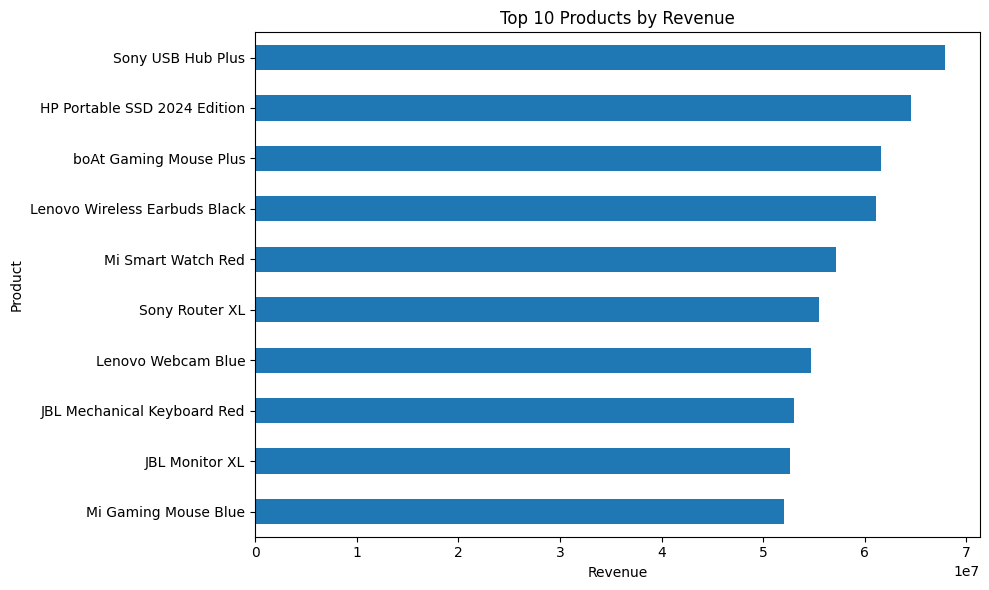

In [36]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

TOP CATEGORIES BY REVENUE

In [37]:
category_revenue = (
    product_sales.groupby("category_name")
    ["line_total"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)


category_name
Electronics         4.501992e+09
Furniture           2.944446e+09
Home & Kitchen      1.088386e+09
Sports & Fitness    6.557541e+08
Automotive          5.400872e+08
Toys & Baby         4.255759e+08
Fashion             2.812562e+08
Books               9.706368e+07
Beauty              9.029379e+07
Grocery             4.329747e+07
Name: line_total, dtype: float64


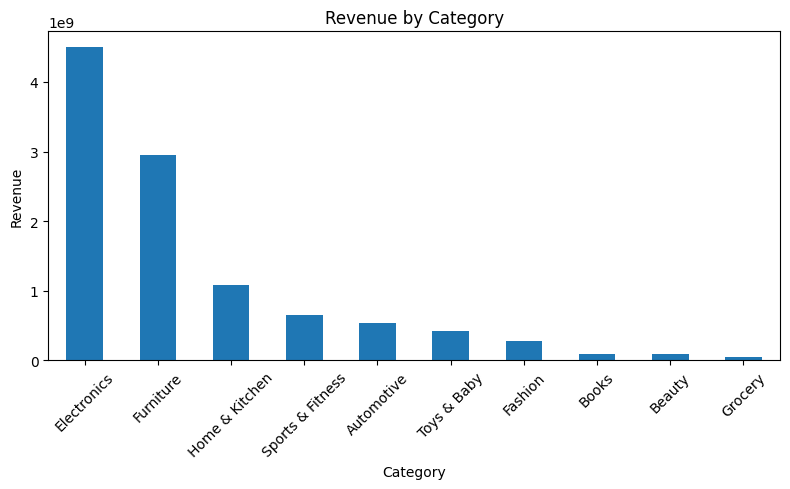

In [38]:
plt.figure(figsize=(8,5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

UNITS SOLD BY CATEGORY

In [39]:
category_quantity = (
    product_sales
    .groupby("category_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(category_quantity)

category_name
Books               114153
Furniture           109789
Electronics         102427
Home & Kitchen      102362
Toys & Baby         100066
Fashion              98989
Grocery              95976
Automotive           89559
Beauty               83173
Sports & Fitness     80057
Name: quantity, dtype: int64


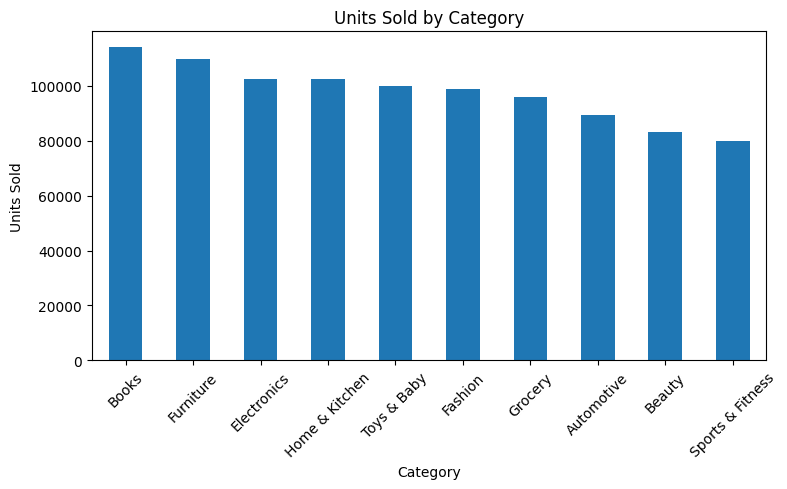

In [40]:
plt.figure(figsize=(8,5))

category_quantity.plot(kind="bar")

plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

PRODUCT PROFIT ANALYSIS

In [41]:
product_sales["Profit"] = (
    (product_sales["unit_price"] - product_sales["cost_price"])
    * product_sales["quantity"]
)

In [42]:
profit = (
    product_sales
    .groupby("product_name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit.head(10)

,Profit
product_name,
Sony USB Hub Plus,16617720.00
HP Portable SSD 2024 Edition,14518123.36
Lenovo Wireless Earbuds Black,14098076.16
boAt Gaming Mouse Plus,13855765.20
Mi Smart Watch Red,13405180.37
JBL Monitor XL,13223098.56
boAt Noise Cancelling Headphones Pro,11880671.68
Wakefit Recliner 2024 Edition,11647782.30
Urban Ladder Side Table Black,11446859.68


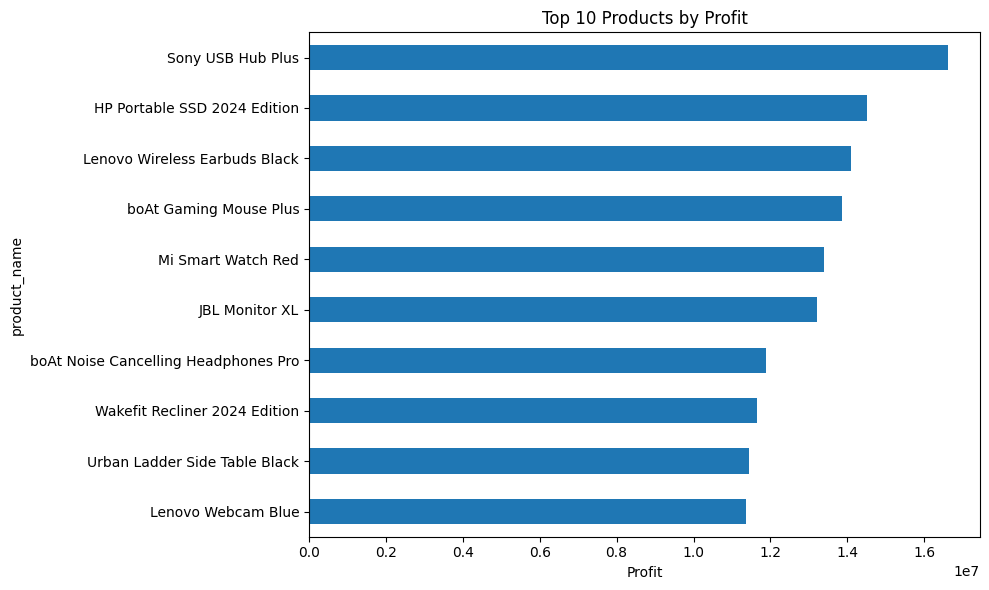

In [43]:
plt.figure(figsize=(10,6))

profit.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

REVENUE DISTRIBUTION

In [44]:
revenue_distribution = (
    product_sales
    .groupby("product_name")["line_total"]
    .sum()
)

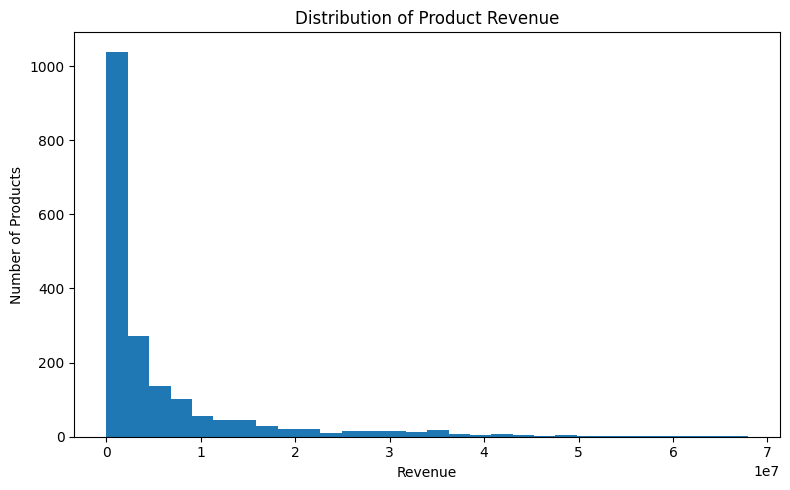

In [45]:
plt.figure(figsize=(8,5))

plt.hist(revenue_distribution, bins=30)

plt.title("Distribution of Product Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

AVERAGE SELLING PRICE BY CATEGORY

In [46]:
avg_price = (
    product_sales
    .groupby("category_name")["unit_price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_price)

category_name
Electronics         47588.317836
Furniture           29060.372502
Home & Kitchen      11519.711190
Sports & Fitness     8866.969960
Automotive           6528.536391
Toys & Baby          4601.660766
Fashion              3082.820506
Beauty               1174.811706
Books                 921.971905
Grocery               488.388443
Name: unit_price, dtype: float64


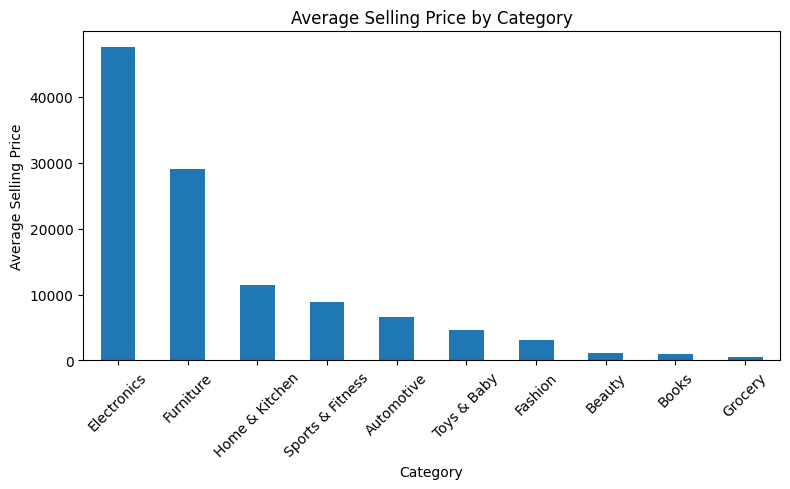

In [47]:
plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.title("Average Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Selling Price")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

CATEGORY CONTRIBUTION TO REVENUE

In [48]:
category_share = (
    product_sales
    .groupby("category_name")["line_total"]
    .sum()
)

In [49]:
category_share = (
    category_share / category_share.sum() * 100
).round(2)

print(category_share)

category_name
Automotive           5.06
Beauty               0.85
Books                0.91
Electronics         42.20
Fashion              2.64
Furniture           27.60
Grocery              0.41
Home & Kitchen      10.20
Sports & Fitness     6.15
Toys & Baby          3.99
Name: line_total, dtype: float64


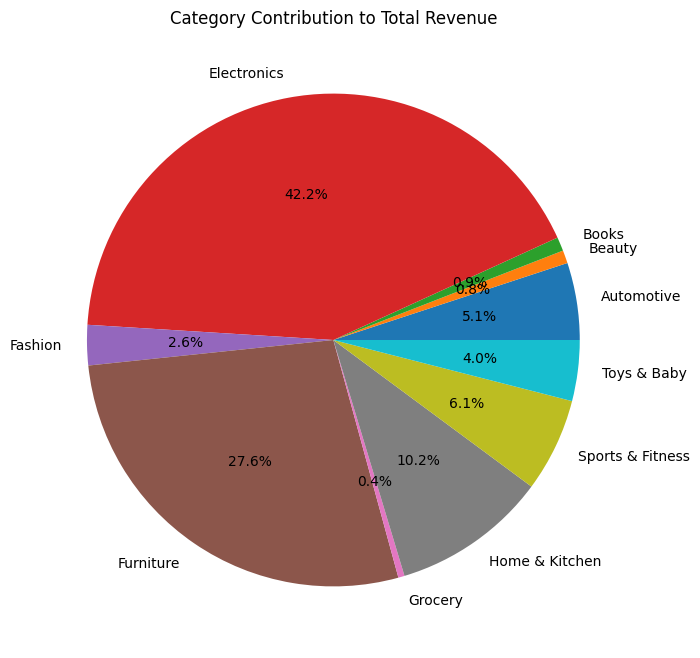

In [50]:
plt.figure(figsize=(8,8))

plt.pie(
    category_share,
    labels=category_share.index,
    autopct="%1.1f%%"
)

plt.title("Category Contribution to Total Revenue")

plt.show()

# CUSTOMER BEHAVIOUR ANALYSIS

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])

orders = orders[
    orders["order_status"] == "Delivered"
].copy()

In [52]:
customer_summary = (
    orders.groupby("customer_id")
    .agg(
        Total_Orders=("order_id","count"),
        Total_Spent=("total_amount","sum"),
        Average_Order_Value=("total_amount","mean")
    )
    .reset_index()
)

customer_summary = customer_summary.merge(
    customers,
    on="customer_id",
    how="left"
)

customer_summary.head()

,customer_id,Total_Orders,Total_Spent,Average_Order_Value,first_name,last_name,gender,age,email,phone,city,state,pincode,signup_date,acquisition_channel,loyalty_tier,is_active
0,100001,1,15031.03,15031.030000,Jhalak,Sachar,Male,55,jhalak.sachar187@gmail.com,8581769315,Kolkata,West Bengal,697124,2023-11-11,Organic,Bronze,True
1,100002,8,269485.05,33685.631250,Xavier,Kulkarni,Male,41,xavier.kulkarni376@gmail.com,7306710475,Mumbai,Maharashtra,743986,2021-12-10,Email,Bronze,True
2,100003,3,145662.76,48554.253333,Jackson,Gour,Female,19,jackson.gour882@outlook.com,6389151677,Mumbai,Maharashtra,137537,2022-04-20,Meta Ads,Bronze,True
3,100004,4,172909.55,43227.387500,Hemal,Oak,Female,28,hemal.oak940@yahoo.com,6056972561,Chennai,Tamil Nadu,350192,2023-04-12,Google Ads,Gold,True
4,100005,1,1144.00,1144.000000,Ishaan,Gour,Female,57,ishaan.gour554@icloud.com,8126768636,Jaipur,Rajasthan,708187,2023-02-16,Organic,Bronze,True


DISTRIBUTION OF ORDERS PER CUSTOMER

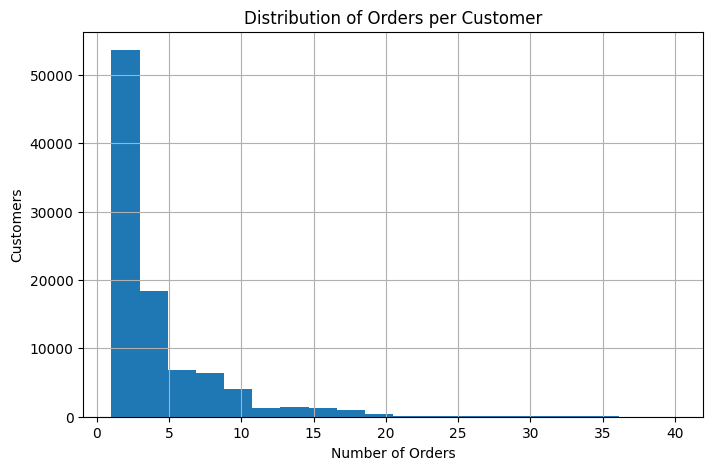

In [53]:
plt.figure(figsize=(8,5))

plt.hist(
    customer_summary["Total_Orders"],
    bins=20
)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")

plt.grid(True)

plt.show()

DISTRIBUTION OF CUSTOMER SPENDING

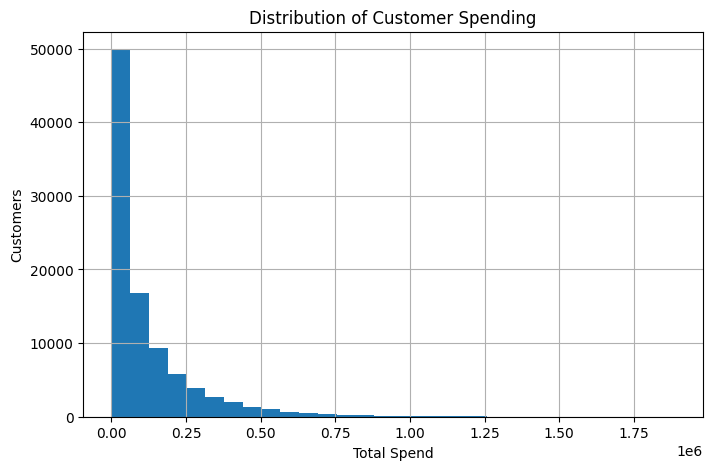

In [54]:
plt.figure(figsize=(8,5))

plt.hist(
    customer_summary["Total_Spent"],
    bins=30
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spend")
plt.ylabel("Customers")

plt.grid(True)

plt.show()

AVERAGE SPEND BY LOYALTY TIER

In [55]:
tier_spending = (
    customer_summary
    .groupby("loyalty_tier")["Total_Spent"]
    .mean()
    .sort_values(ascending=False)
)

print(tier_spending)

loyalty_tier
Gold        121120.150811
Silver      119417.744642
Bronze      118335.860406
Platinum    117647.548957
Name: Total_Spent, dtype: float64


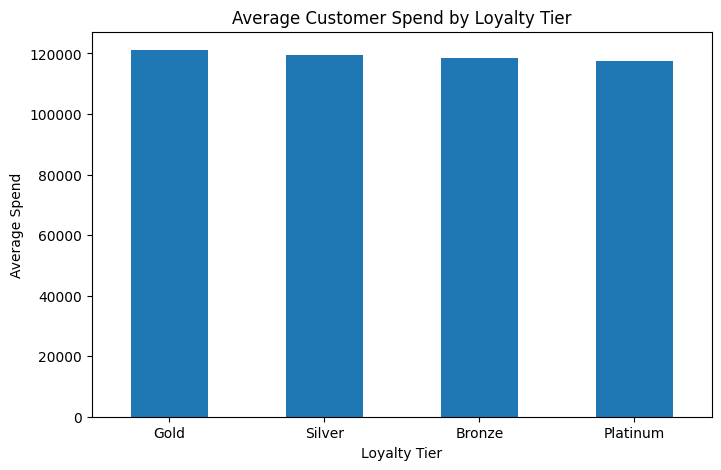

In [56]:
plt.figure(figsize=(8,5))

tier_spending.plot(kind="bar")

plt.title("Average Customer Spend by Loyalty Tier")
plt.xlabel("Loyalty Tier")
plt.ylabel("Average Spend")

plt.xticks(rotation=0)

plt.show()

ACQUISISTION CHANNEL PERFORMANCE

In [57]:
channel = (
    customer_summary
    .groupby("acquisition_channel")
    .agg(
        Customers=("customer_id","count"),
        Avg_Spend=("Total_Spent","mean"),
        Avg_Orders=("Total_Orders","mean")
    )
    .round(2)
)

print(channel)

                     Customers  Avg_Spend  Avg_Orders
acquisition_channel                                  
Affiliate                 3887  120335.00        3.82
Email                     9432  117282.14        3.64
Google Ads               23935  118962.95        3.68
Meta Ads                 17183  120481.54        3.73
Organic                  33081  117356.93        3.65
Referral                  7831  122369.21        3.82


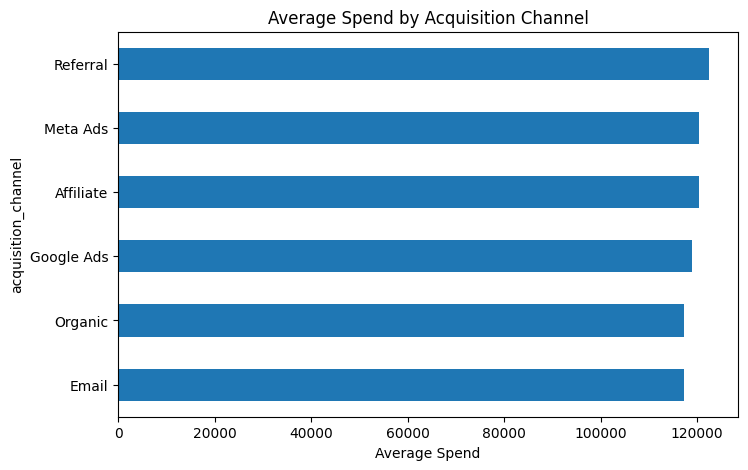

In [58]:
plt.figure(figsize=(8,5))

channel["Avg_Spend"].sort_values().plot(kind="barh")

plt.title("Average Spend by Acquisition Channel")
plt.xlabel("Average Spend")

plt.show()

TOP 10 CUSTOMERS

In [60]:
top_customers = (
    customer_summary
    .sort_values(
        by="Total_Spent",
        ascending=False
    )
)

top_customers[
    [
        "customer_id",
        "first_name",
        "last_name",
        "Total_Spent",
        "Total_Orders",
        "Average_Order_Value"
    ]
].head(10)

,customer_id,first_name,last_name,Total_Spent,Total_Orders,Average_Order_Value
4492,104718,Indira,Parsa,1887428.47,31,60884.789355
26587,127877,Jeremiah,Kunda,1842547.86,34,54192.584118
65583,168761,Azad,Chandran,1838092.16,31,59293.295484
25562,126799,Peter,Bal,1825297.69,37,49332.370000
84264,188361,Bina,Zachariah,1783814.13,36,49550.392500
3224,103396,Vidhi,Bail,1752604.68,38,46121.175789
21377,122417,Faras,Ravel,1740785.34,31,56154.365806
7341,107701,Gaurika,Sama,1739417.82,34,51159.347647
55988,158693,Sneha,Dube,1738295.21,28,62081.971786
79117,182967,Mohini,Sodhi,1709071.55,32,53408.485938


CUSTOMER AGE VS AVERAGE SPEND

In [61]:
age_spending = (
    customer_summary
    .groupby("age")["Total_Spent"]
    .mean()
)


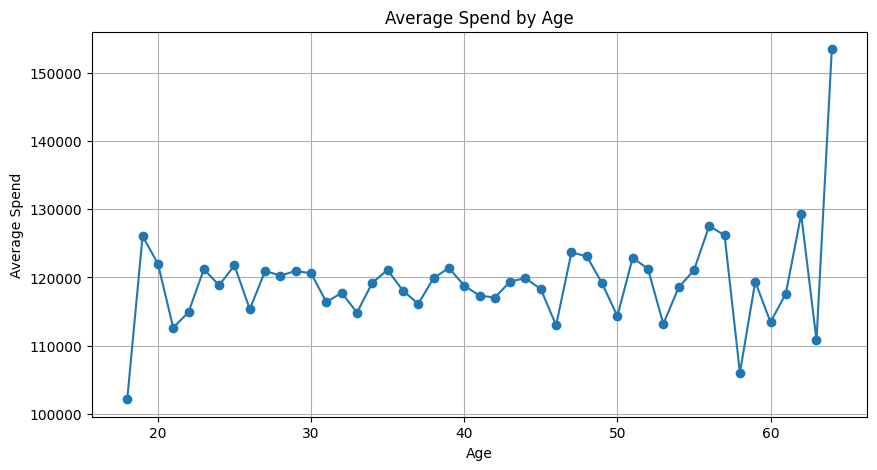

In [62]:
plt.figure(figsize=(10,5))

plt.plot(
    age_spending.index,
    age_spending.values,
    marker="o"
)

plt.title("Average Spend by Age")
plt.xlabel("Age")
plt.ylabel("Average Spend")

plt.grid(True)

plt.show()

ACTIVE VS INACTIVE CUSTOMERS

In [63]:
activity = (
    customer_summary["is_active"]
    .value_counts()
)

print(activity)

is_active
True     90581
False     4768
Name: count, dtype: int64


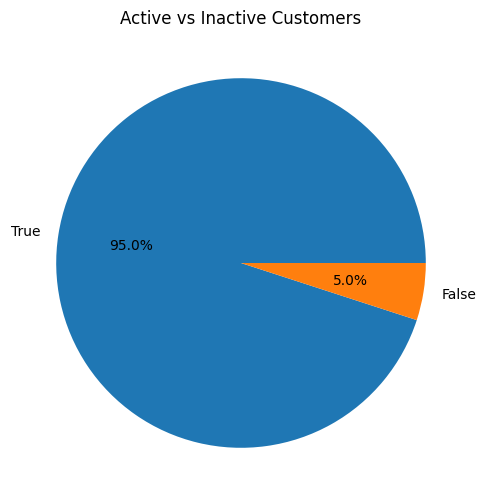

In [64]:
plt.figure(figsize=(6,6))

plt.pie(
    activity,
    labels=activity.index,
    autopct="%1.1f%%"
)

plt.title("Active vs Inactive Customers")

plt.show()

TOP 10 CITIES BY CUSTOMER SPENDING

In [65]:
city_sales = (
    customer_summary
    .groupby("city")["Total_Spent"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(city_sales)

city
Mumbai       1.693375e+09
Delhi        1.485688e+09
Bengaluru    1.334126e+09
Hyderabad    1.132583e+09
Chennai      9.066367e+08
Pune         8.949358e+08
Kolkata      7.044274e+08
Ahmedabad    6.701154e+08
Jaipur       5.757807e+08
Lucknow      5.631877e+08
Name: Total_Spent, dtype: float64


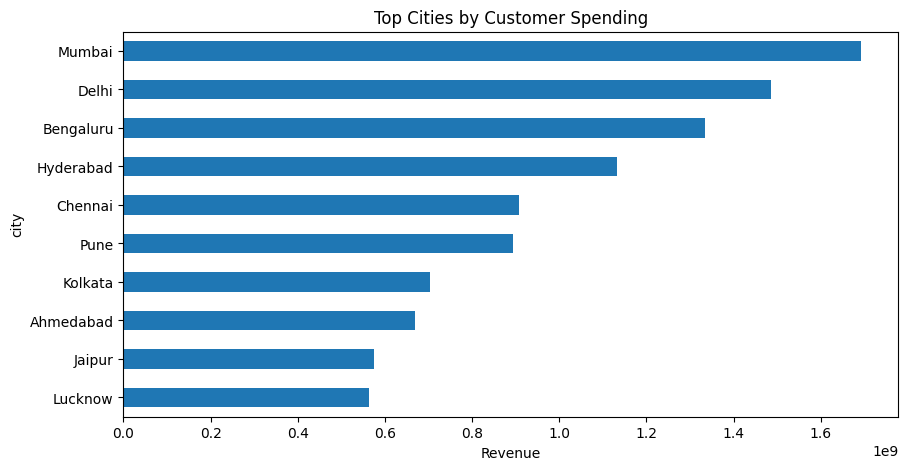

In [66]:
plt.figure(figsize=(10,5))

city_sales.sort_values().plot(kind="barh")

plt.title("Top Cities by Customer Spending")
plt.xlabel("Revenue")

plt.show()

CORRELATION BETWEEN ORDERS AND SPENDING

In [67]:
correlation = customer_summary[
    ["Total_Orders","Total_Spent"]
].corr()

print(correlation)

              Total_Orders  Total_Spent
Total_Orders      1.000000     0.847066
Total_Spent       0.847066     1.000000


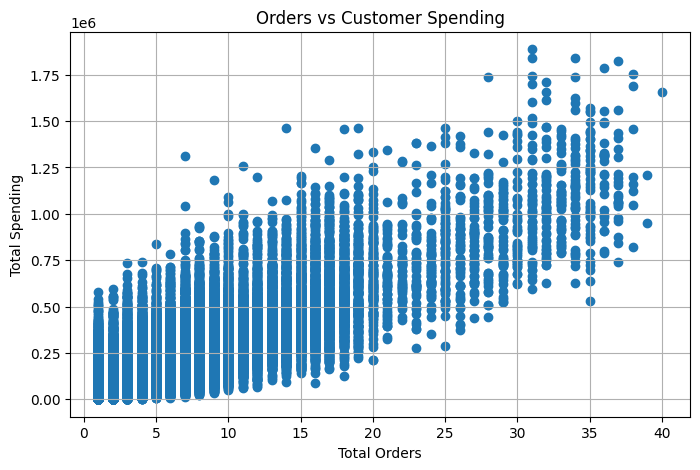

In [68]:
plt.figure(figsize=(8,5))

plt.scatter(
    customer_summary["Total_Orders"],
    customer_summary["Total_Spent"]
)

plt.title("Orders vs Customer Spending")
plt.xlabel("Total Orders")
plt.ylabel("Total Spending")

plt.grid(True)

plt.show()

# RETURN AND REVIEWS ANALYSIS

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

returns = pd.read_csv("returns.csv")
reviews = pd.read_csv("reviews.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")
categories = pd.read_csv("categories.csv")

In [70]:
returns["return_date"] = pd.to_datetime(returns["return_date"])
reviews["review_date"] = pd.to_datetime(reviews["review_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])

OVERALL RETURN RATE

In [71]:
total_orders = orders["order_id"].nunique()

returned_orders = returns["order_id"].nunique()

return_rate = (
    returned_orders / total_orders
) * 100

print(f"Return Rate: {return_rate:.2f}%")

Return Rate: 3.05%


RETURN REASONS

In [72]:
return_reason = (
    returns["return_reason"]
    .value_counts()
)

print(return_reason)

return_reason
Changed Mind               2420
Quality Not as Expected    2401
Damaged Product            2391
Size/Fit Issue             1786
Defective Product          1745
Wrong Item Delivered       1196
Name: count, dtype: int64


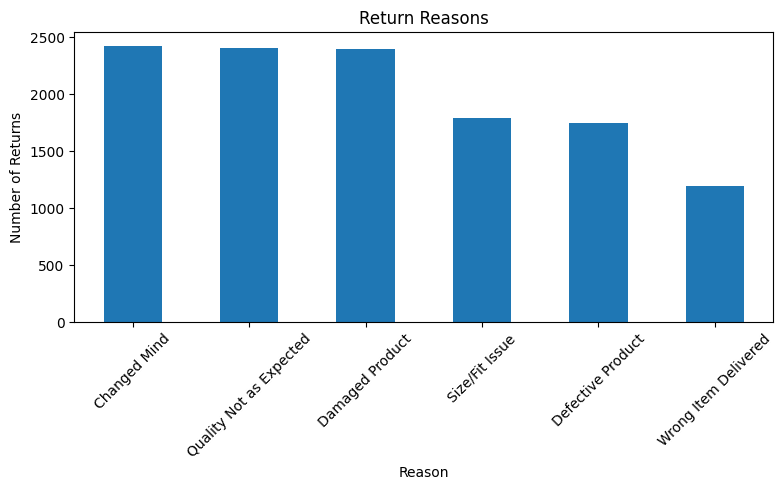

In [73]:
plt.figure(figsize=(8,5))

return_reason.plot(kind="bar")

plt.title("Return Reasons")
plt.xlabel("Reason")
plt.ylabel("Number of Returns")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

REFUND AMOUNT DISTRIBUTION

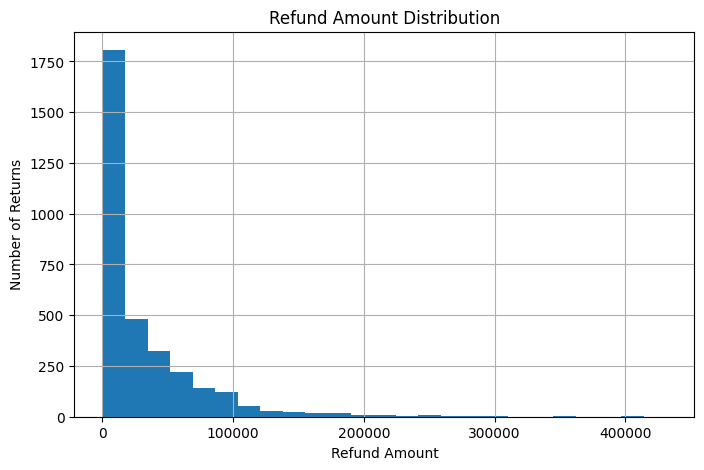

In [74]:
plt.figure(figsize=(8,5))

plt.hist(
    returns["refund_amount"],
    bins=25
)

plt.title("Refund Amount Distribution")
plt.xlabel("Refund Amount")
plt.ylabel("Number of Returns")

plt.grid(True)

plt.show()

MONTHLY RETURNS

In [75]:
returns["Month"] = (
    returns["return_date"]
    .dt.to_period("M")
    .astype(str)
)


In [76]:
monthly_returns = (
    returns.groupby("Month")["return_id"]
    .count()
)

print(monthly_returns)

Month
2021-01       1
2021-02       7
2021-03      13
2021-04      13
2021-05      25
2021-06      21
2021-07      32
2021-08      35
2021-09      50
2021-10      79
2021-11     110
2021-12      85
2022-01      55
2022-02      48
2022-03      57
2022-04      64
2022-05      80
2022-06      66
2022-07      96
2022-08     112
2022-09     136
2022-10     206
2022-11     242
2022-12     236
2023-01     143
2023-02     117
2023-03     149
2023-04     157
2023-05     147
2023-06     163
2023-07     181
2023-08     238
2023-09     273
2023-10     366
2023-11     471
2023-12     483
2024-01     272
2024-02     257
2024-03     306
2024-04     305
2024-05     317
2024-06     326
2024-07     447
2024-08     542
2024-09     631
2024-10     896
2024-11    1130
2024-12    1215
2025-01     538
Name: return_id, dtype: int64


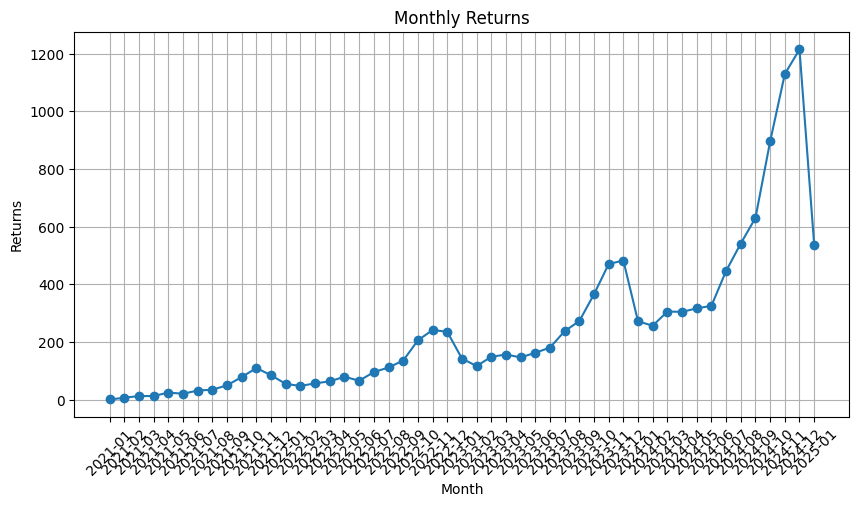

In [77]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_returns.index,
    monthly_returns.values,
    marker="o"
)

plt.title("Monthly Returns")
plt.xlabel("Month")
plt.ylabel("Returns")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

AVERAGE RATING

In [78]:
print(
    "Average Rating:",
    round(reviews["rating"].mean(),2)
)

Average Rating: 4.14


RATING DISTRIBUTION

In [79]:
rating_counts = (
    reviews["rating"]
    .value_counts()
    .sort_index()
)

print(rating_counts)

rating
1     10866
2     18224
3     43870
4    127455
5    163713
Name: count, dtype: int64


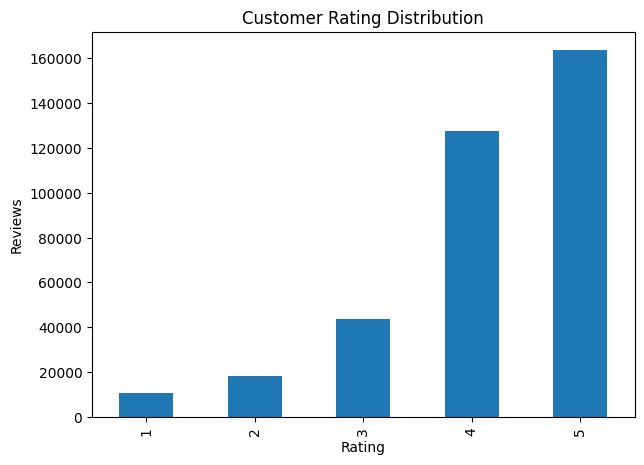

In [80]:
plt.figure(figsize=(7,5))

rating_counts.plot(kind="bar")

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Reviews")

plt.show()

AVERAGE RATING BY CATEGORY

In [81]:
review_data = (
    reviews
    .merge(order_items,on="order_id")
    .merge(products,on="product_id")
    .merge(categories,on="category_id")
)

In [82]:
category_rating = (
    review_data
    .groupby("category_name")["rating"]
    .mean()
    .sort_values(ascending=False)
)

print(category_rating)

category_name
Automotive          4.143369
Books               4.142555
Fashion             4.142304
Toys & Baby         4.140892
Beauty              4.140534
Electronics         4.139824
Home & Kitchen      4.138238
Sports & Fitness    4.137802
Grocery             4.135069
Furniture           4.132840
Name: rating, dtype: float64


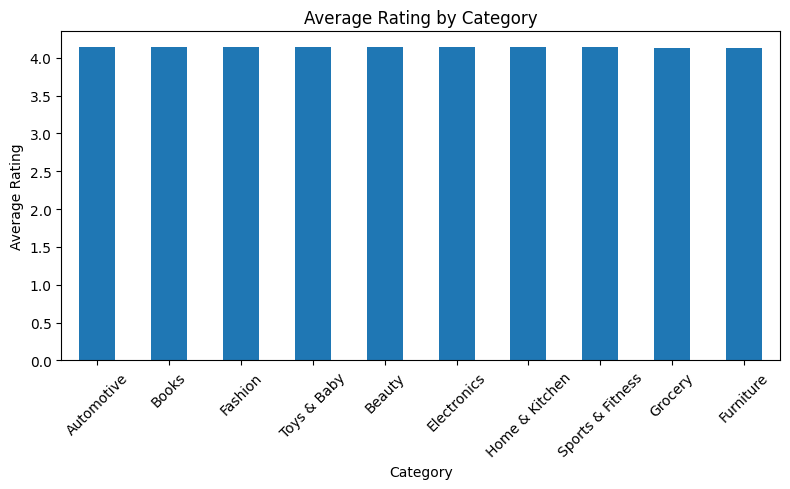

In [83]:
plt.figure(figsize=(8,5))

category_rating.plot(kind="bar")

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

RETURNS BY CATEGORY

In [84]:
return_category = (
    returns
    .merge(order_items,on="order_id")
    .merge(products,on="product_id")
    .merge(categories,on="category_id")
)

category_returns = (
    return_category
    .groupby("category_name")["return_id"]
    .count()
    .sort_values(ascending=False)
)

print(category_returns)

category_name
Books               2729
Furniture           2550
Toys & Baby         2419
Electronics         2334
Home & Kitchen      2309
Grocery             2295
Fashion             2286
Automotive          2047
Beauty              1871
Sports & Fitness    1837
Name: return_id, dtype: int64


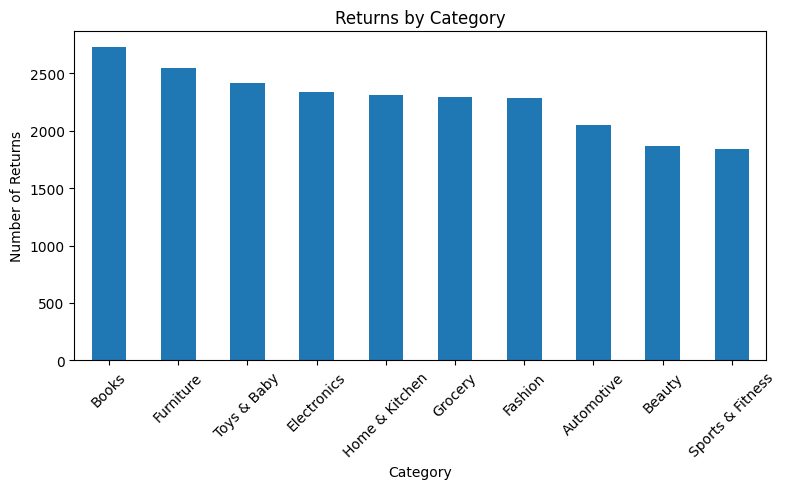

In [85]:
plt.figure(figsize=(8,5))

category_returns.plot(kind="bar")

plt.title("Returns by Category")
plt.xlabel("Category")
plt.ylabel("Number of Returns")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

REFUND STATUS

In [86]:
refund_status = (
    returns["refund_status"]
    .value_counts()
)

print(refund_status)

refund_status
Processed    11359
Pending        580
Name: count, dtype: int64


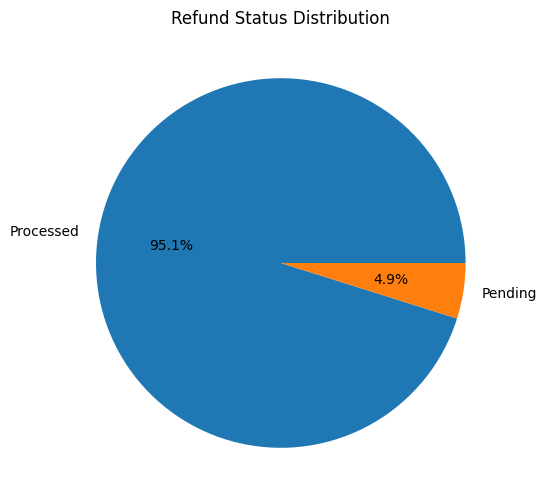

In [87]:
plt.figure(figsize=(6,6))

plt.pie(
    refund_status,
    labels=refund_status.index,
    autopct="%1.1f%%"
)

plt.title("Refund Status Distribution")

plt.show()